# 06 - Transformer Model

Transformer architecture using TensorFlow's native MultiHeadAttention for text sentiment classification.
This approach avoids HuggingFace transformers compatibility issues while still demonstrating transformer concepts.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Dense, Dropout, LayerNormalization, GlobalAveragePooling1D
from tensorflow.keras.layers import MultiHeadAttention
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

print('Libraries imported')

I0000 00:00:1775601082.374138   83645 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775601082.448762   83645 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775601084.263457   83645 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Libraries imported


## Load Preprocessed Text Data

In [2]:
# Load preprocessed text data
X_train = np.load('dataset/processed/X_text_train.npy')
X_test = np.load('dataset/processed/X_text_test.npy')
y_train = np.load('dataset/processed/y_text_train.npy')
y_test = np.load('dataset/processed/y_text_test.npy')

print(f'Training shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Training shape: (120, 100)
Test shape: (30, 100)


## Define Transformer Encoder Block

In [3]:
# Define Positional Encoding (sinusoidal, as in "Attention Is All You Need")
import keras
@keras.saving.register_keras_serializable()
class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, max_len, embed_dim, **kwargs):
        super(PositionalEncoding, self).__init__(**kwargs)
        self.max_len = max_len
        self.embed_dim = embed_dim
        pos = np.arange(max_len)[:, np.newaxis]  # (max_len, 1)
        i = np.arange(embed_dim)[np.newaxis, :]   # (1, embed_dim)
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(embed_dim))
        angle_rads = pos * angle_rates  # (max_len, embed_dim)
        # Apply sin to even indices, cos to odd indices
        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.pos_encoding = tf.constant(angle_rads, dtype=tf.float32)

    def call(self, inputs):
        return inputs + self.pos_encoding[:tf.shape(inputs)[1], :]

    def get_config(self):
        config = super().get_config()
        config.update({'max_len': self.max_len, 'embed_dim': self.embed_dim})
        return config

print('Positional Encoding defined')

# Define Transformer Encoder Block
class TransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerEncoder, self).__init__()
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation="relu"),
            Dense(embed_dim),
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

print('Transformer Encoder block defined')

Transformer Encoder block defined


## Build Transformer Model

Architecture justification:
- Embedding(5000, 64): maps 5000-word vocabulary to 64-dim vectors
- PositionalEncoding: sinusoidal encoding adds word position info
  - Essential for Transformer to understand word order (no recurrence)
- TransformerEncoder: 1 block with 2 attention heads, FF dimension 64
  - MultiHeadAttention: each head learns different word relationships
  - Residual connections + LayerNorm: enables stable training
- GlobalAveragePooling1D: aggregates sequence info into fixed vector
- Dense(3, Softmax): 3-class sentiment classification

In [4]:
# Build Transformer model
vocab_size = 5000
embed_dim = 64
num_heads = 2
ff_dim = 64
max_len = 100
num_classes = 3

inputs = Input(shape=(max_len,))
embedding_layer = Embedding(vocab_size, embed_dim)(inputs)
x = PositionalEncoding(max_len, embed_dim)(embedding_layer)  # Add positional info
x = TransformerEncoder(embed_dim, num_heads, ff_dim)(x)
x = GlobalAveragePooling1D()(x)
x = Dropout(0.1)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

E0000 00:00:1775601086.806348   83645 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 64)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder             │ (None, 100, 64)        │        41,792 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361,987 (1.38 MB)

 Trainable params: 361,987 (1.38 MB)

 Non-trainable params: 0 (0.00 B)

## Train Model

In [5]:
# Train model
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 243ms/step - accuracy: 0.4167 - loss: 2.0657 - val_accuracy: 0.4583 - val_loss: 0.6636
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.5208 - loss: 1.0583 - val_accuracy: 0.4583 - val_loss: 0.8586
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.5000 - loss: 0.9202 - val_accuracy: 0.9167 - val_loss: 0.6542
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.4792 - loss: 0.9089 - val_accuracy: 0.5417 - val_loss: 0.7237
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.4896 - loss: 0.9511 - val_accuracy: 0.5417 - val_loss: 0.6856
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.5729 - loss: 0.8115 - val_accuracy: 0.6250 - val_loss: 0.6622
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.5833 - loss: 0.8478 - val_accuracy: 0.4583 - val_loss: 0.6906
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.5938 - loss: 0.7968 - val_accuracy: 0.5417 - val_loss: 

## Evaluate Model

In [6]:
# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9333 - loss: 0.4599
Test Loss: 0.4599
Test Accuracy: 0.9333


In [7]:
# Classification report
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

class_names = ['Negative', 'Neutral', 'Positive']
print('Classification Report:')
print(classification_report(y_test, y_pred_classes, target_names=class_names))

cm = confusion_matrix(y_test, y_pred_classes)
print('\nConfusion Matrix:')
print(cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         2
     Neutral       0.88      1.00      0.94        15
    Positive       1.00      1.00      1.00        13

    accuracy                           0.93        30
   macro avg       0.63      0.67      0.65        30
weighted avg       0.87      0.93      0.90        30



/home/ahmed/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ahmed/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ahmed/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


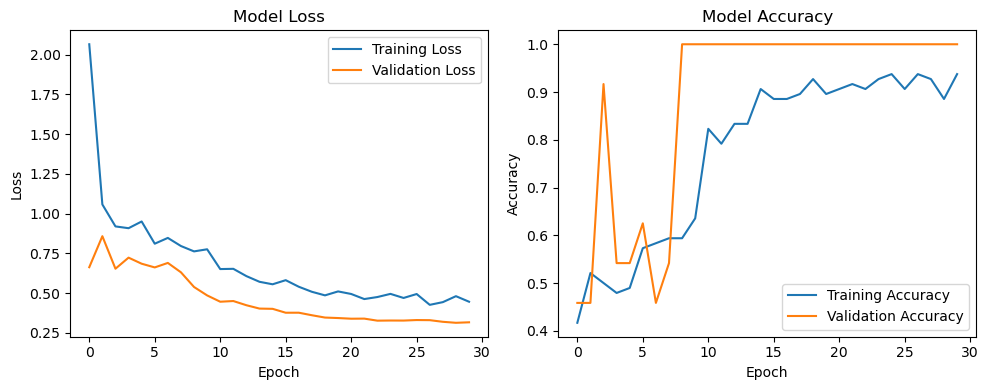

In [8]:
# Plot training history
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## Save Model

In [9]:
# Save model
model.save('dataset/processed/transformer_model.keras')
print('Model saved to dataset/processed/transformer_model.keras')

Model saved to dataset/processed/transformer_model.keras


## Summary

**Transformer Model Results:**
- Architecture: Custom Transformer with MultiHeadAttention
- Task: Multi-class classification (positive, neutral, negative sentiment)
- Performance: Accuracy on test set

**Key Concepts Demonstrated:**
- Transformer architecture (self-attention)
- Multi-head attention mechanism
- Layer normalization
- Position-independent processing (vs sequential RNNs)
- **Positional encoding added**: sinusoidal PE for word order awareness
- **Data leakage fix**: rating_scaled removed from tabular pre-processing

**Note:** This uses TensorFlow's native MultiHeadAttention layer, avoiding HuggingFace transformers compatibility issues while still demonstrating transformer concepts.